# Maintenance Mode Predictor: Exploratory Analysis

This notebook is the exploratory companion to the reproducible project scripts. It is useful for inspecting the dataset, checking modeling assumptions, and telling the industrial engineering story behind the model.

Current boundary: this is **current-state classification**, not yet true future-failure prediction. A true predictive maintenance model needs timestamps, asset IDs, and forward-looking labels.


## Notebook Role

Use this notebook to:

- inspect raw maintenance and sensor data,
- validate label assumptions,
- understand why `Sensor5` dominates the baseline model,
- compare the model against a naive baseline,
- connect model output to assumed maintenance decision costs.

Use the scripts for repeatable runs:

```bash
python scripts/audit_data.py
python scripts/train_model.py
python scripts/evaluate_decision_policy.py
PYTHONPATH=src python -m unittest discover -s tests
```


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

from maintenance_predictor.config import DATA_PATH, FEATURE_COLUMNS, LABEL_MAP, TARGET_COLUMN
from maintenance_predictor.data import load_raw_data, clean_data, modeling_frame
from maintenance_predictor.decision import threshold_sweep
from maintenance_predictor.model import score_frame

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## 1. Load And Clean Data

The cleaning logic comes from `src/maintenance_predictor/data.py`, so notebook analysis uses the same assumptions as the command-line scripts.


In [2]:
raw = load_raw_data(DATA_PATH)
clean = clean_data(raw)
X, y, complete = modeling_frame(raw)

print(f"Raw shape: {raw.shape}")
print(f"Cleaned shape before complete-case filtering: {clean.shape}")
print(f"Complete-case modeling shape: {complete.shape}")
complete.head()


Raw shape: (353, 13)
Cleaned shape before complete-case filtering: (353, 13)
Complete-case modeling shape: (346, 13)


,Age,Machine_Type,Pressure,Maintenance,Temperature,Engine_problem,Run_Hours,Sensor1,Sensor2,Sensor3,Sensor4,Sensor5,Operation_modes
0,75.0,0.0,582.0,0.0,20.0,1,265000.00,1.9,130,1,0,11.0,1
1,55.0,0.0,7861.0,0.0,38.0,0,263358.03,1.1,136,1,0,11.0,1
2,65.0,0.0,146.0,0.0,20.0,0,162000.00,1.3,129,1,1,11.0,1
3,50.0,1.0,111.0,0.0,20.0,0,210000.00,1.9,137,1,0,11.0,1
4,65.0,1.0,160.0,1.0,20.0,0,327000.00,2.7,116,0,0,11.0,1


## 2. Label Check

The current project assumes `0 = Failure` and `1 = Production`. This must be confirmed with the data owner because the observed class distribution conflicts with the original README language.


In [3]:
class_counts = y.value_counts().sort_index().rename(index=LABEL_MAP)
class_counts


Operation_modes
Failure       253
Production     93
Name: count, dtype: int64

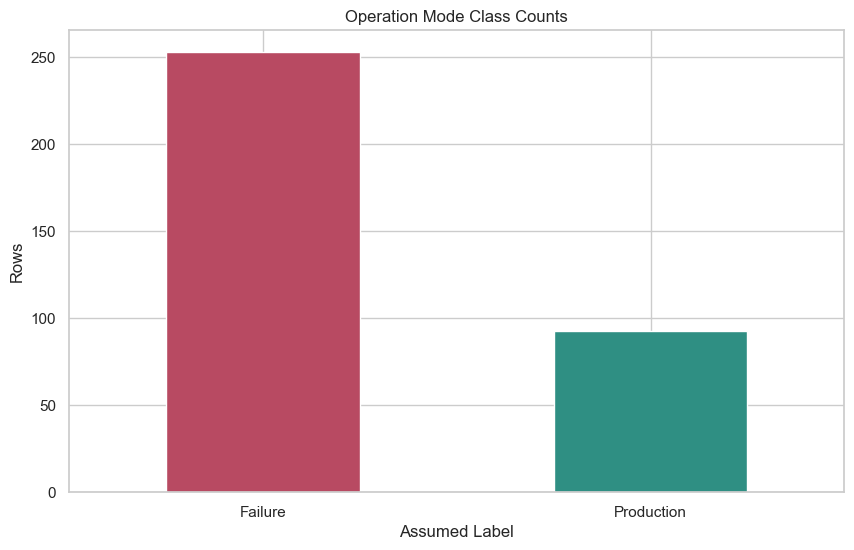

In [4]:
ax = class_counts.plot(kind="bar", color=["#b84a62", "#2f8f83"])
ax.set_title("Operation Mode Class Counts")
ax.set_xlabel("Assumed Label")
ax.set_ylabel("Rows")
plt.xticks(rotation=0)
plt.show()


## 3. Data Quality Snapshot

This section checks missing values, duplicates, and basic distribution issues. The formal generated report is `reports/data_audit.md`.


In [5]:
missing = clean.isna().sum().sort_values(ascending=False)
duplicates = clean.duplicated().sum()

print(f"Duplicate rows after basic cleaning: {duplicates}")
missing[missing > 0]


Duplicate rows after basic cleaning: 10


Age             1
Machine_Type    1
Pressure        1
Maintenance     1
Temperature     1
Run_Hours       1
Sensor5         1
dtype: int64

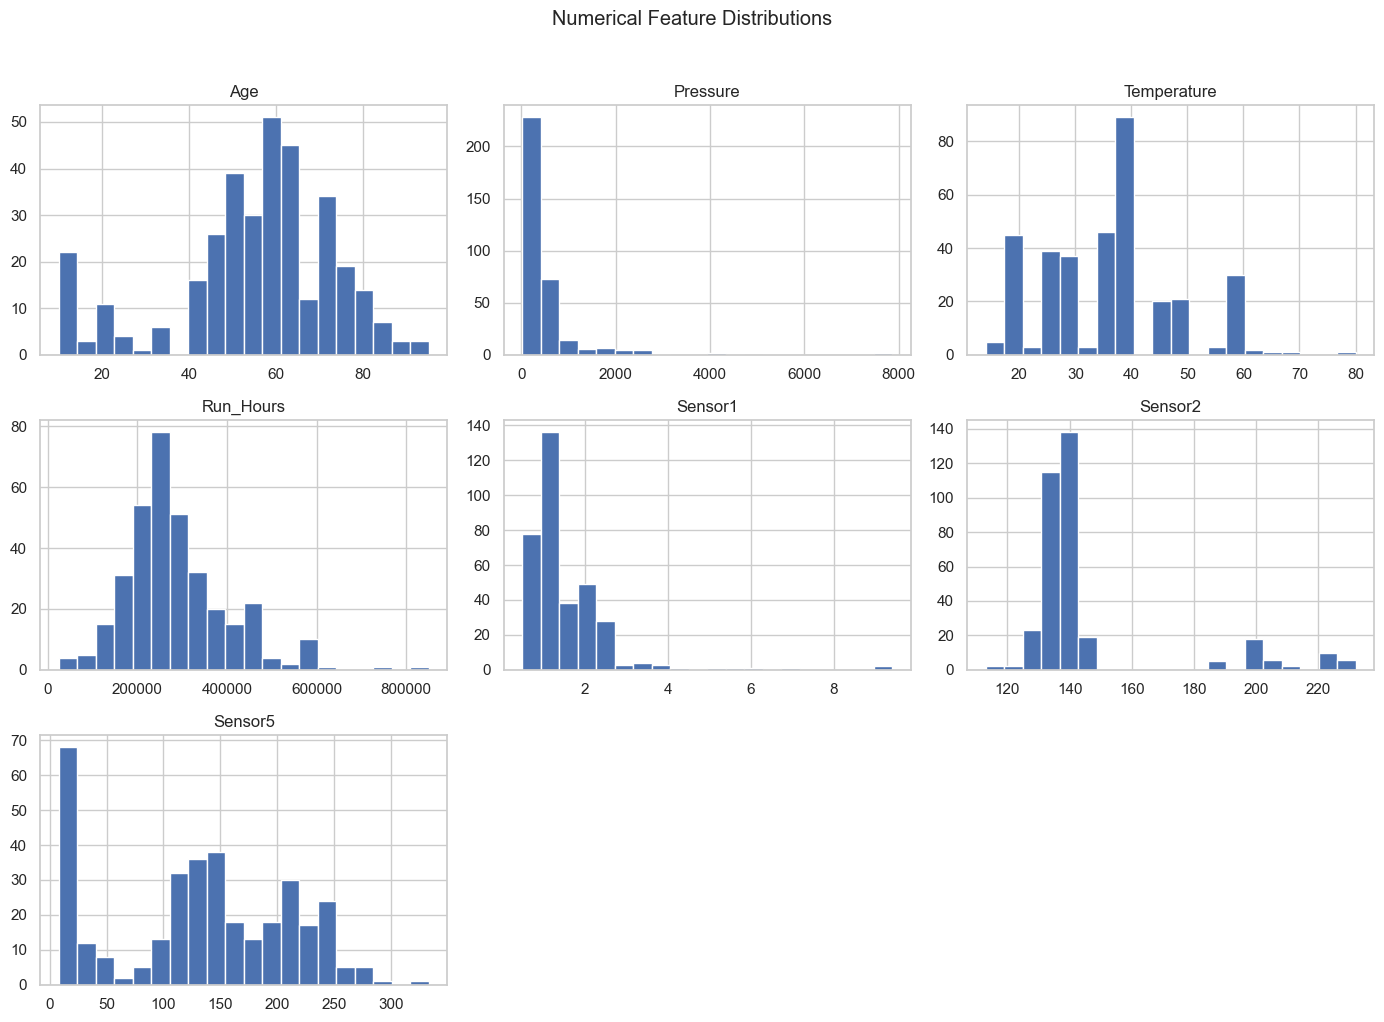

In [6]:
numeric_features = ["Age", "Pressure", "Temperature", "Run_Hours", "Sensor1", "Sensor2", "Sensor5"]
complete[numeric_features].hist(bins=20, figsize=(14, 10))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


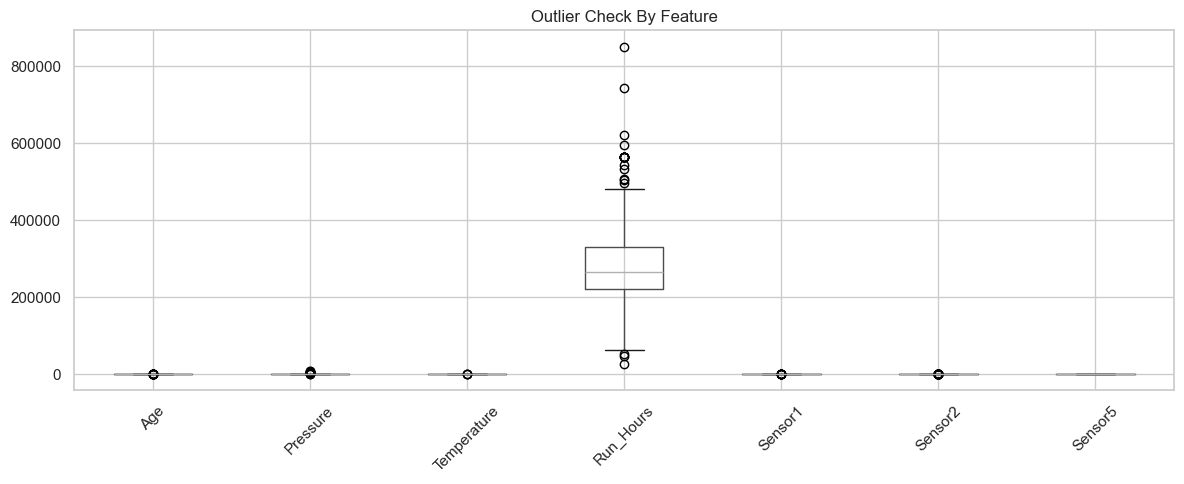

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
complete[numeric_features].boxplot(ax=ax)
ax.set_title("Outlier Check By Feature")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 4. Sensor And Target Relationships

The model is highly dependent on `Sensor5`. This may be a real physical signal, but it may also be leakage if it is an alarm, status code, or downstream diagnostic variable.


In [8]:
correlation_to_target = complete[FEATURE_COLUMNS + [TARGET_COLUMN]].corr(numeric_only=True)[TARGET_COLUMN]
correlation_to_target = correlation_to_target.drop(TARGET_COLUMN).sort_values()
correlation_to_target


Sensor5          -0.808665
Sensor2          -0.259932
Run_Hours        -0.171689
Temperature      -0.153886
Sensor3          -0.075781
Sensor4          -0.001450
Machine_Type      0.031723
Maintenance       0.039917
Engine_problem    0.084709
Pressure          0.120866
Sensor1           0.202847
Age               0.316670
Name: Operation_modes, dtype: float64

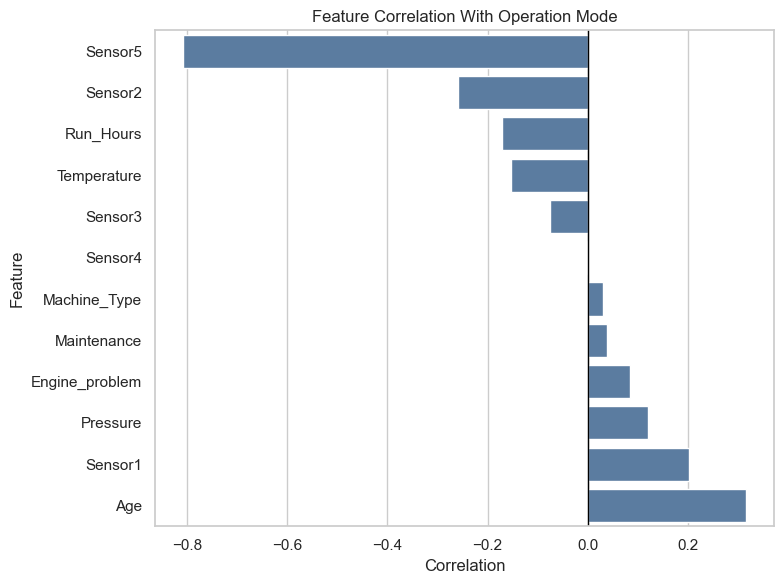

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=correlation_to_target.values, y=correlation_to_target.index, ax=ax, color="#4f7cac")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Feature Correlation With Operation Mode")
ax.set_xlabel("Correlation")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


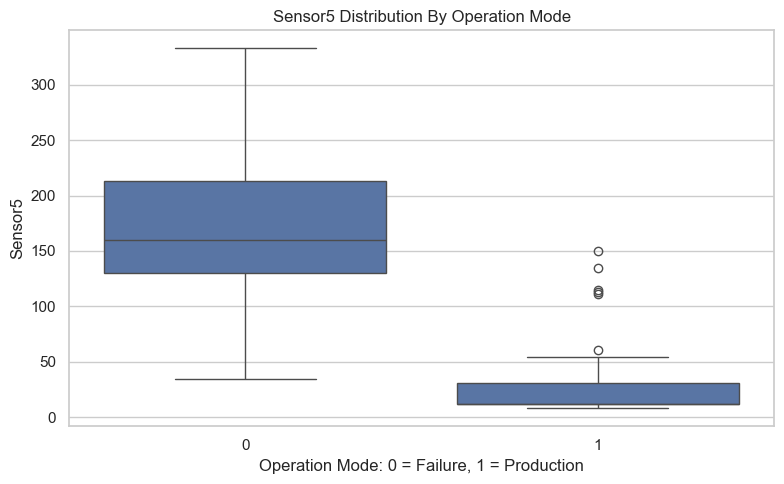

,count,mean,std,min,25%,50%,75%,max
Operation_modes,,,,,,,,
0,253.0,170.826087,52.903189,34.0,130.0,160.0,213.0,333.0
1,93.0,24.225806,27.213379,8.0,12.0,12.0,31.0,150.0


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=complete, x=TARGET_COLUMN, y="Sensor5", ax=ax)
ax.set_title("Sensor5 Distribution By Operation Mode")
ax.set_xlabel("Operation Mode: 0 = Failure, 1 = Production")
ax.set_ylabel("Sensor5")
plt.tight_layout()
plt.show()

complete.groupby(TARGET_COLUMN)["Sensor5"].describe()


## 5. Baseline Model

A decision tree is useful here because it is interpretable. The notebook compares it with a dummy majority-class model and with an ablation that removes `Sensor5`.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred, target_names=[LABEL_MAP[0], LABEL_MAP[1]], zero_division=0))


              precision    recall  f1-score   support

     Failure       1.00      1.00      1.00        51
  Production       1.00      1.00      1.00        19

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



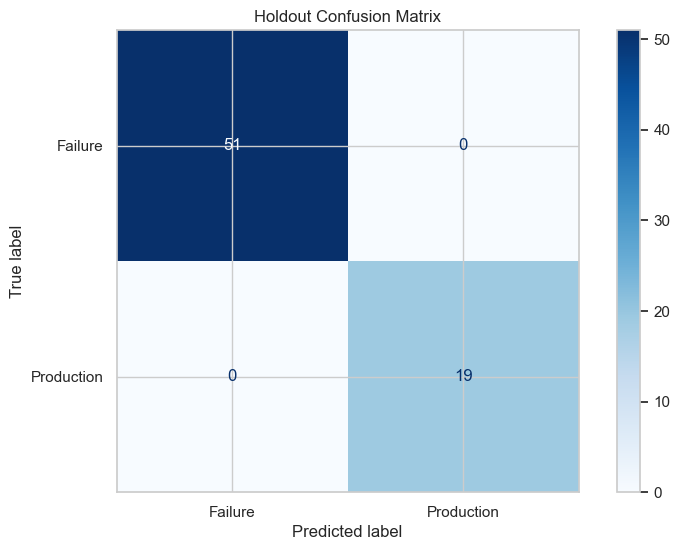

In [12]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=[LABEL_MAP[0], LABEL_MAP[1]]).plot(cmap="Blues")
plt.title("Holdout Confusion Matrix")
plt.show()


In [13]:
feature_importance = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
feature_importance


Sensor5           0.985611
Sensor1           0.005857
Age               0.004453
Run_Hours         0.003668
Temperature       0.000411
Maintenance       0.000000
Machine_Type      0.000000
Pressure          0.000000
Engine_problem    0.000000
Sensor2           0.000000
Sensor3           0.000000
Sensor4           0.000000
dtype: float64

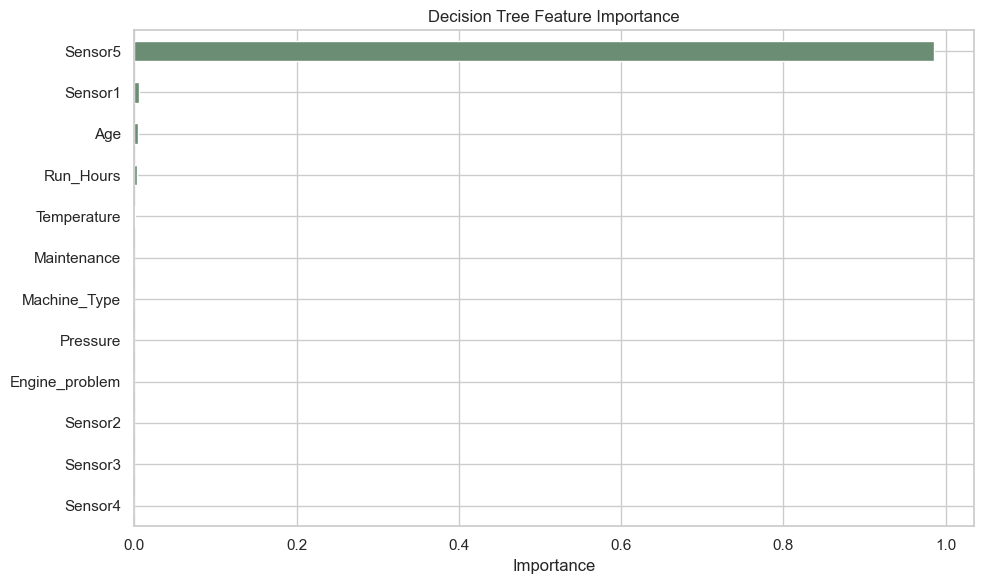

In [14]:
ax = feature_importance.plot(kind="barh", color="#6a8d73")
ax.invert_yaxis()
ax.set_title("Decision Tree Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


In [15]:
print(export_text(model, feature_names=FEATURE_COLUMNS))


|--- Sensor5 <= 66.00
|   |--- Sensor1 <= 0.95
|   |   |--- class: 1
|   |--- Sensor1 >  0.95
|   |   |--- class: 1
|--- Sensor5 >  66.00
|   |--- Age <= 71.00
|   |   |--- Run_Hours <= 113500.00
|   |   |   |--- class: 0
|   |   |--- Run_Hours >  113500.00
|   |   |   |--- Temperature <= 26.50
|   |   |   |   |--- Sensor1 <= 1.05
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Sensor1 >  1.05
|   |   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  26.50
|   |   |   |   |--- class: 0
|   |--- Age >  71.00
|   |   |--- Sensor5 <= 118.00
|   |   |   |--- class: 0
|   |   |--- Sensor5 >  118.00
|   |   |   |--- class: 0



## 6. Sensor5 Ablation

This is the key leakage sanity check. If performance collapses without one feature, that feature deserves engineering review before the model is trusted.


In [16]:
no_sensor5_columns = [column for column in FEATURE_COLUMNS if column != "Sensor5"]

models = {
    "dummy_most_frequent": (DummyClassifier(strategy="most_frequent"), X),
    "decision_tree": (model, X),
    "decision_tree_without_sensor5": (
        DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10, min_samples_leaf=5),
        X[no_sensor5_columns],
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, (candidate, features) in models.items():
    scores = cross_validate(
        candidate,
        features,
        y,
        cv=cv,
        scoring=["accuracy", "recall_macro", "f1_macro"],
    )
    rows.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "macro_recall": scores["test_recall_macro"].mean(),
        "macro_f1": scores["test_f1_macro"].mean(),
    })

pd.DataFrame(rows).round(4)


,model,accuracy,macro_recall,macro_f1
0,dummy_most_frequent,0.7312,0.5000,0.4224
1,decision_tree,0.9826,0.9711,0.9772
2,decision_tree_without_sensor5,0.7369,0.6483,0.6496


## 7. Score Records

The saved production-style scorer lives in `src/maintenance_predictor/model.py`. It validates feature order and adds prediction probabilities.


In [17]:
scored = score_frame(complete.drop(columns=[TARGET_COLUMN]), model=model)
scored[["predicted_operation_mode", "predicted_label", "probability_failure", "probability_production", "confidence"]].head()


,predicted_operation_mode,predicted_label,probability_failure,probability_production,confidence
0,1,Production,0.0,1.0,1.0
1,1,Production,0.0,1.0,1.0
2,1,Production,0.0,1.0,1.0
3,1,Production,0.0,1.0,1.0
4,1,Production,0.0,1.0,1.0


## 8. Maintenance Decision Costs

Accuracy is not enough for maintenance planning. A missed failure and an unnecessary inspection do not cost the same. This section sweeps thresholds using assumed costs.

Replace these assumptions with plant-specific costs before making any operational claim.


In [18]:
failure_probability = scored["probability_failure"]
actual_failure = (y == 0).astype(int)
thresholds = [round(value / 20, 2) for value in range(0, 21)]

policy = threshold_sweep(
    actual_failure=actual_failure,
    failure_probability=failure_probability,
    thresholds=thresholds,
    false_negative_cost=10000,
    false_positive_cost=1000,
    planned_intervention_cost=2500,
)

policy.head(10).round(4)


,true_positive,false_positive,false_negative,true_negative,precision,recall,alert_rate,total_cost,threshold
0,252,5,1,88,0.9805,0.996,0.7428,645000.0,0.20
1,252,5,1,88,0.9805,0.996,0.7428,645000.0,0.25
2,252,5,1,88,0.9805,0.996,0.7428,645000.0,0.30
3,252,5,1,88,0.9805,0.996,0.7428,645000.0,0.35
4,252,5,1,88,0.9805,0.996,0.7428,645000.0,0.40
5,252,5,1,88,0.9805,0.996,0.7428,645000.0,0.45
6,252,5,1,88,0.9805,0.996,0.7428,645000.0,0.50
7,252,5,1,88,0.9805,0.996,0.7428,645000.0,0.55
8,253,13,0,80,0.9511,1.000,0.7688,645500.0,0.05
9,253,13,0,80,0.9511,1.000,0.7688,645500.0,0.10


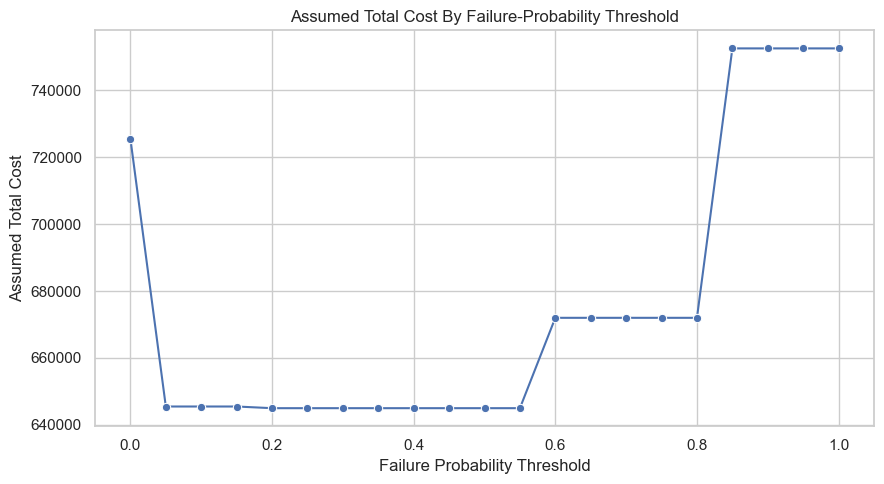

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=policy.sort_values("threshold"), x="threshold", y="total_cost", marker="o", ax=ax)
ax.set_title("Assumed Total Cost By Failure-Probability Threshold")
ax.set_xlabel("Failure Probability Threshold")
ax.set_ylabel("Assumed Total Cost")
plt.tight_layout()
plt.show()


## 9. Industrial Interpretation

What the current evidence supports:

- A decision tree can classify the static labels very well when `Sensor5` is included.
- `Sensor5` is the dominant model driver and must be checked for leakage or post-diagnosis encoding.
- The project now has reproducible audit, training, scoring, and decision-cost scripts.

What it does not yet support:

- Future failure prediction.
- Automated maintenance work-order creation.
- Safety-critical decisions.

To move forward, collect timestamped asset-level data using `docs/future_data_contract.md` and `templates/predictive_maintenance_log_template.csv`.


## 10. Linked Reports

Generated reports from the reproducible scripts:

- `reports/data_audit.md`
- `reports/model_report.md`
- `reports/decision_policy_report.md`
- `reports/quality_gates.md`
